In [1]:
from sys import path
path.append('../')

from numpy import (array, empty, arange, linspace, meshgrid, logical_and as land,
                   abs, sqrt, exp, log, sin, cos, pi as π)
from numpy.linalg import inv, det
from numpy.random import default_rng
my_rng = default_rng()
uniform, normal, lognormal = my_rng.random, my_rng.normal, my_rng.lognormal

%matplotlib inline
%config InlineBackend.figure_format='retina'  # Only use for high-dpi monitors (such as mac book pros)
import matplotlib.pyplot as plt

from pyregress import GPI, Noise, SquareExp, LogNormal

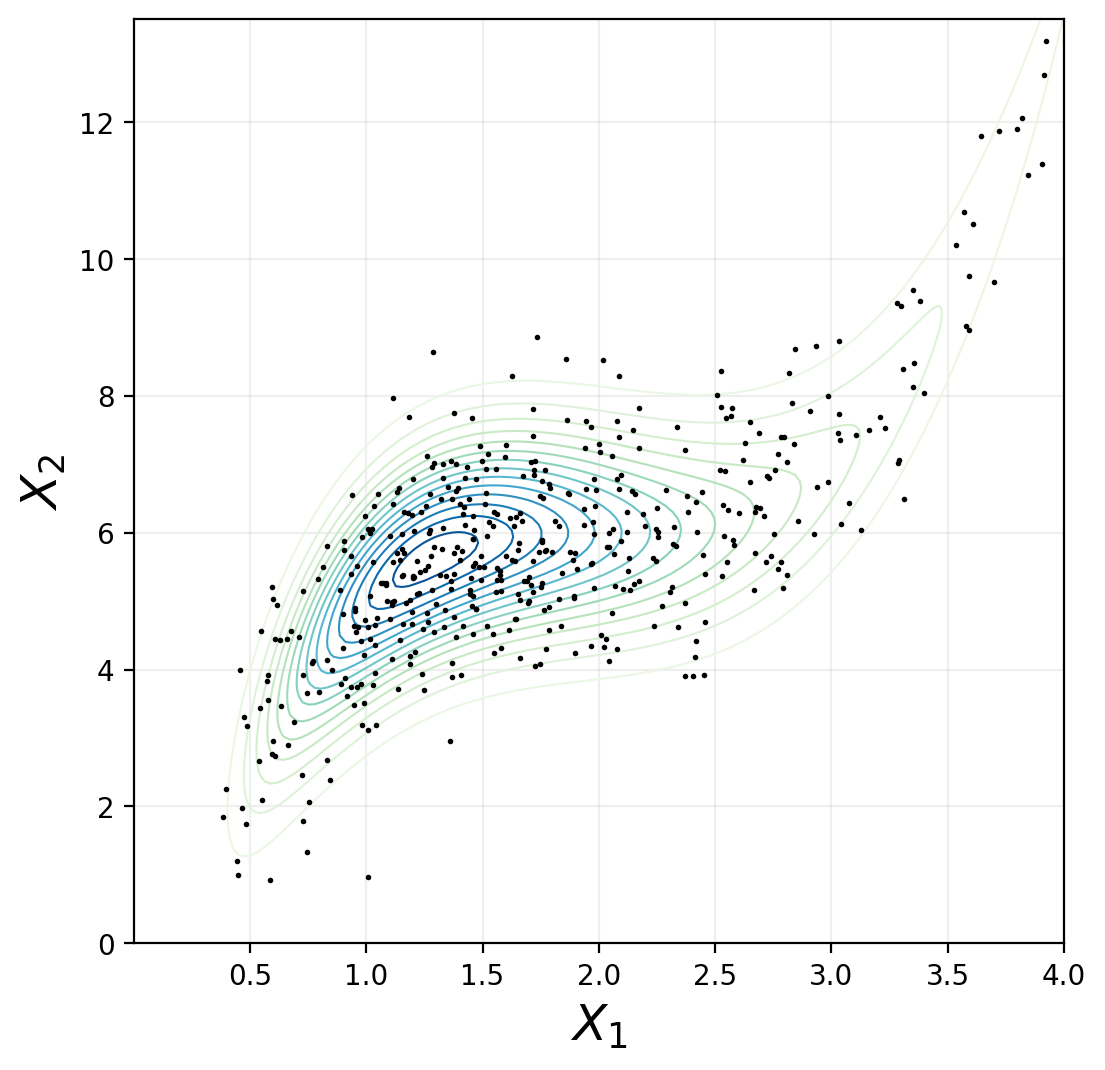

In [2]:
n_samples = 500
x_samples = empty((2, n_samples))

# # Option #1:
# x_samples[0, :] = lognormal(3.0, 0.6, n_samples)
# x_samples[1, :] = normal(3, 2, n_samples)
# x_samples[1, :] += 8e-3 * x_samples[0]**2
# θ = π/3
# A = array([[cos(θ), -sin(θ)], [sin(θ), cos(θ)]])
# x_samples= A @ x_samples
# n1, n2 = 150, 151
# Ainv = inv(A)
# detA = det(A)
# x1_grid = linspace(-6, 11, n1)
# x2_grid = linspace( 1, 90, n2)
# x_dist = empty((n1, n2))
# for i in range(n1):
#     for j in range(n2):
#         x1_prime = Ainv[0, 0] * x1_grid[i] + Ainv[0, 1] * x2_grid[j]
#         x1 = log(abs(x1_prime))
#         x2 = Ainv[1, 0] * x1_grid[i] + Ainv[1, 1] * x2_grid[j] - 8e-3 * x1_prime**2
#         x_dist[i, j] = (exp(-0.5 * (((x1 - 3.0) / 0.6)**2 + ((x2 - 3.0) / 2.0)**2))
#                         / (2 * π * 0.6 * 2.0 * detA * x1_prime))
# X_grids = meshgrid(x1_grid, x2_grid, indexing='ij')

# Option #2:
σ2 = 1.0
x_samples[0] = lognormal(0.5, 0.5, n_samples)
x_samples[1] = (x_samples[0] - 2)**3 + 6 + normal(0, σ2, n_samples)
n1, n2 = 150, 151
x1_grid = linspace(1e-3, 4, n1)
x2_grid = linspace(0, 13.5, n2)
x_dist = empty((n1, n2))
for i in range(n1):
    for j in range(n2):
        x1 = log(x1_grid[i])
        x2 = x2_grid[j] - (x1_grid[i] - 2)**3 - 6
        x_dist[i, j] = (exp(-0.5 * (((x1 - 0.5) / 0.5)**2 + ((x2 - 0) / σ2)**2)) /
                        (2 * π * 0.5 * σ2 * x1_grid[i]))
X_grids = meshgrid(x1_grid, x2_grid, indexing='ij')

plt.figure(figsize=(6, 6))
plt.contour(*X_grids, x_dist, levels=15, cmap='GnBu', linewidths=0.75)
plt.plot(x_samples[0], x_samples[1], linestyle='none', color='black', marker='o', markersize=1)
plt.xlim(x1_grid[0], x1_grid[-1])
plt.ylim(x2_grid[0], x2_grid[-1])
plt.xlabel('$X_1$', fontsize=18)
plt.ylabel('$X_2$', fontsize=18)
plt.grid(True, alpha=0.2) ;

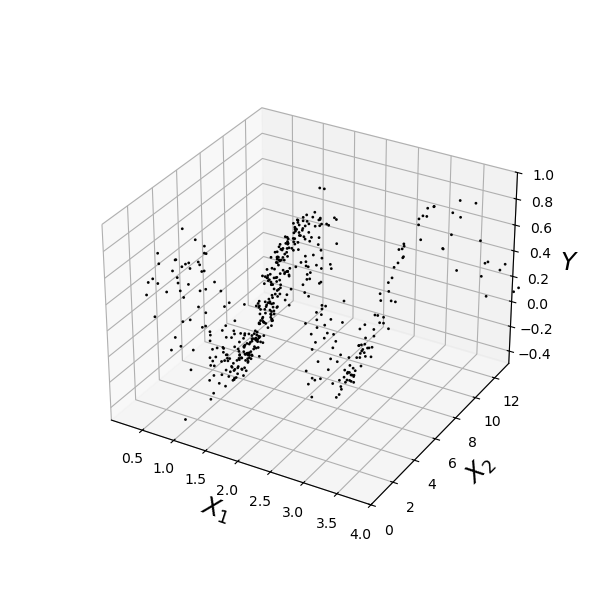

In [3]:
def my_func(x):
    # return 0.5 * sin((2 * π / 6.5) * x[0]) + 0.5e-2 * x[1] + 5.1e-2 * normal(0, 1, x[0].shape)
    return 0.5 * sin((2 * π / 1.5) * x[0]) + 4.5e-2 * x[1] + 5.1e-2 * normal(0, 1, x[0].shape)
y_samples = my_func(x_samples)

%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D 
plt.close()
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(x_samples[0], x_samples[1], y_samples, color='black', s=1)
ax.set_xlim(x1_grid[0], x1_grid[-1])
ax.set_ylim(x2_grid[0], x2_grid[-1])
ax.set_zlim(-0.5, 1.0)
ax.set_xlabel('$X_1$', fontsize=18)
ax.set_ylabel('$X_2$', fontsize=18)
ax.set_zlabel('$Y$', fontsize=18) ;

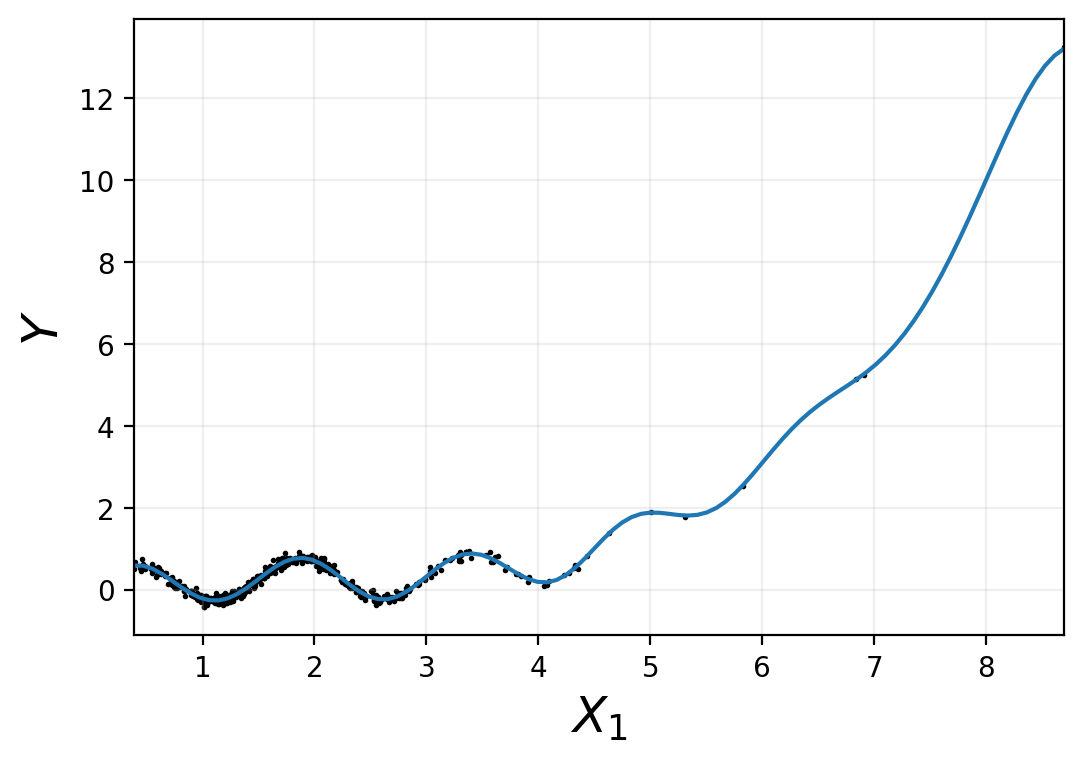

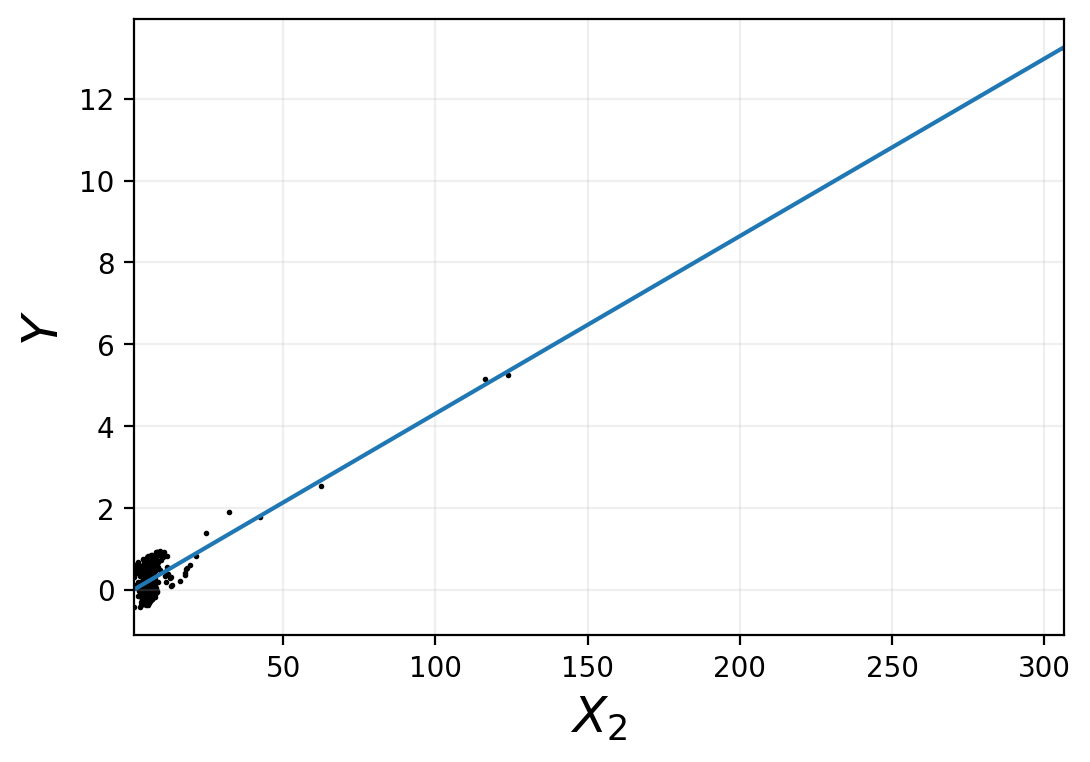

In [4]:
# Functional behavior of the conditional expectation
plt.close()
%matplotlib inline
for i, x_i in enumerate(x_samples):
    std_y = y_samples.std()
    Kern = (Noise(w=LogNormal(guess=std_y, σ=0.35)) +
            SquareExp(w=std_y, l=LogNormal(guess=0.2, σ=0.35)))
    my_gpi = GPI(x_i.reshape((-1, 1)), y_samples, Kern, Xscaling='range', explicit_basis=[0, 1])
    x_grid = linspace(x_i.min(), x_i.max(), 100)
    y_fit = my_gpi(x_grid)
    plt.figure(figsize=(6, 4))
    plt.scatter(x_i, y_samples, color='black', s=1)
    plt.plot(x_grid, y_fit)
    plt.xlim(x_grid[0], x_grid[-1])
    plt.grid(True, alpha=0.2)
    plt.xlabel(f'$X_{i + 1}$', fontsize=18)
    plt.ylabel('$Y$', fontsize=18)

In [ ]:
# 2D proof of concept (nD algorithm would be different):
n_bins = 25
gradients = []
for i, ni in zip(range(2), reversed(range(2))):
    xi = x_samples[i]
    xni = x_samples[ni]
    Δi = (xi.max() - xi.min()) / n_bins
    Δni = (xni.max() - xni.min()) / n_bins
    grad_xi = []
    for j in range(n_bins):
        bin_mask = land(xni.min() + j * Δni <= xni, xni <= xni.min() + (j + 1) * Δni)
        bin_ind = arange(xni.shape[0])[bin_mask]
        for k0 in bin_ind:
            for k1 in bin_ind:
                if k0 == k1:
                    continue
                grad_xi.append((y_samples[k0] - y_samples[k1]) / (xi[k0] - xi[k1]))
    gradients.append(Δi * array(grad_xi))

In [ ]:
gradients[1].std()

In [ ]:
plt.scatter([abs(gradients[i]).mean() for i in range(2)],
            [gradients[i].std() for i in range(2)]) ;

In [ ]:
bins = []
n_bins = 25
for xi in x_samples:
    Δ = (xi.max() - xi.min()) / n_bins
    xi_bins = []
    for j in range(n_bins):
        bin_mask = land(xi.min() + j * Δ <= xi, xi <= xi.min() + (j + 1) * Δ)
        bin_ind = arange(xi.shape[0])[bin_mask]
        xi_bins.append(set(bin_ind))
    bins.append(xi_bins)